# EEG Data Pipeline — 11-685 Guided Project

**Person 1 notebook**: dataset exploration, quality checks, master DataFrame, train/val/test splits, PyTorch DataLoader.

Outputs used by Person 2 (baseline MLP) and Person 3 (CLIP warm-up):
- `artifacts/master_trials.csv`, `train.csv`, `val.csv`, `test.csv`
- `artifacts/label_mappings.pkl`
- `EEGDataset` class + `eeg_collate_fn`

## 1. Setup & Configuration

In [74]:
import os, sys, json, pickle, warnings
from pathlib import Path, PureWindowsPath
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paths ──
EEG_ROOT    = "/ocean/projects/cis250019p/gandotra/11785-gp-eeg/ds005589"
PROJECT_DIR = "/jet/home/sharmar/eeg-project"
CAPTIONS_PATH = os.path.join(PROJECT_DIR, "captions.txt")
IMAGES_DIR    = os.path.join(PROJECT_DIR, "images")
OUTPUT_DIR    = os.path.join(PROJECT_DIR, "artifacts")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Enumerate subjects / sessions / runs ──
SUBJECTS = sorted([d for d in os.listdir(EEG_ROOT) if d.startswith("sub-")])
SESSIONS = [f"ses-{i:02d}" for i in range(1, 6)]
RUNS     = [f"run-{i:02d}" for i in range(1, 5)]
N_CLASSES = 20

print(f"Subjects ({len(SUBJECTS)}): {SUBJECTS}")
print(f"Sessions: {SESSIONS}")
print(f"Runs:     {RUNS}")

Subjects (13): ['sub-02', 'sub-03', 'sub-05', 'sub-09', 'sub-14', 'sub-15', 'sub-17', 'sub-19', 'sub-20', 'sub-23', 'sub-24', 'sub-28', 'sub-29']
Sessions: ['ses-01', 'ses-02', 'ses-03', 'ses-04', 'ses-05']
Runs:     ['run-01', 'run-02', 'run-03', 'run-04']


## 2. Dataset Exploration

In [75]:
# Verify every expected file exists
missing, found = [], []
for sub in SUBJECTS:
    for ses in SESSIONS:
        for run in RUNS:
            prefix = f"{sub}_{ses}_task-lowSpeed_{run}"
            paths = {
                'npy': os.path.join(EEG_ROOT, sub, ses, f"{prefix}_1000Hz.npy"),
                'csv': os.path.join(EEG_ROOT, sub, ses, f"{prefix}_image.csv"),
                'json': os.path.join(EEG_ROOT, sub, ses, f"{prefix}_1000Hz.json"),
            }
            for kind, p in paths.items():
                (found if os.path.exists(p) else missing).append((sub, ses, run, kind, p))

print(f"Found : {len(found)} files")
print(f"Missing: {len(missing)} files")
if missing:
    print("\nFirst 10 missing:")
    for m in missing[:10]:
        print(f"  {m[0]} / {m[1]} / {m[2]} — {m[3]}")

Found : 780 files
Missing: 0 files


In [76]:
# ── Inspect CSV format ──
sample_csv_path = os.path.join(
    EEG_ROOT, SUBJECTS[0], SESSIONS[0],
    f"{SUBJECTS[0]}_{SESSIONS[0]}_task-lowSpeed_run-01_image.csv"
)
sample_csv = pd.read_csv(sample_csv_path)
print("=== CSV columns ===")
print(sample_csv.columns.tolist())
print(f"Rows: {len(sample_csv)}")
print(sample_csv.head())

print("\n=== captions.txt ===")
captions_df = pd.read_csv(CAPTIONS_PATH, sep='\t')
print(f"Columns: {captions_df.columns.tolist()}")
print(f"Rows: {len(captions_df)}")
print(captions_df.head())
print(f"\nCategories ({captions_df['category'].nunique()}):")
print(sorted(captions_df['category'].unique()))

=== CSV columns ===
['FilePath']
Rows: 100
                                            FilePath
0  C:\Users\Huawei\Desktop\eeg_pascal_imagenet\pi...
1  C:\Users\Huawei\Desktop\eeg_pascal_imagenet\pi...
2  C:\Users\Huawei\Desktop\eeg_pascal_imagenet\pi...
3  C:\Users\Huawei\Desktop\eeg_pascal_imagenet\pi...
4  C:\Users\Huawei\Desktop\eeg_pascal_imagenet\pi...

=== captions.txt ===
Columns: ['dataset', 'category', 'image_name', 'abstracted']
Rows: 9825
    dataset category       image_name  \
0  ImageNet  bicycle   n02835271_1031   
1  ImageNet  bicycle  n02835271_10424   
2  ImageNet  bicycle  n02835271_10469   
3  ImageNet  bicycle   n02835271_1055   
4  ImageNet  bicycle  n02835271_10778   

                                    abstracted  
0  Tandem bicycle parked beside a wooden fence  
1    Tandem bicycle leaning against brick wall  
2        Bicycle leaning against a wooden post  
3    Tandem bicycle parked beside green bushes  
4        Tandem bicycle parked by a brick wall  

Cat

In [77]:
# ── Inspect JSON metadata ──
sample_json_path = os.path.join(
    EEG_ROOT, SUBJECTS[0], SESSIONS[0],
    f"{SUBJECTS[0]}_{SESSIONS[0]}_task-lowSpeed_run-01_1000Hz.json"
)
with open(sample_json_path) as f:
    sample_meta = json.load(f)

# Print top-level keys and a preview
if isinstance(sample_meta, dict):
    for k, v in sample_meta.items():
        v_str = str(v)[:120]
        print(f"{k}: {v_str}")
else:
    print(type(sample_meta), str(sample_meta)[:300])

<class 'list'> [10, 9, 16, 18, 17, 9, 4, 4, 3, 4, 11, 15, 5, 11, 18, 10, 16, 4, 3, 16, 10, 19, 17, 2, 13, 7, 5, 0, 11, 5, 14, 19, 6, 9, 13, 6, 15, 1, 4, 3, 5, 14, 16, 8, 2, 17, 2, 7, 1, 12, 17, 8, 18, 13, 7, 12, 19, 15, 0, 18, 11, 1, 0, 12, 3, 9, 8, 11, 13, 7, 19, 1, 0, 15, 13, 6, 8, 19, 1, 6, 12, 3, 5, 0, 7, 9, 8


## 3. Data Quality Scan

In [78]:
quality_records = []

for sub in tqdm(SUBJECTS, desc="Scanning subjects"):
    for ses in SESSIONS:
        for run in RUNS:
            prefix = f"{sub}_{ses}_task-lowSpeed_{run}"
            npy_path = os.path.join(EEG_ROOT, sub, ses, f"{prefix}_1000Hz.npy")
            csv_path = os.path.join(EEG_ROOT, sub, ses, f"{prefix}_image.csv")

            if not os.path.exists(npy_path):
                quality_records.append(dict(
                    subject=sub, session=ses, run=run,
                    issue='npy_missing', shape=None,
                    csv_rows=None, has_nan=None, has_inf=None,
                    mean=None, std=None, min_val=None, max_val=None,
                    shape_ok=False, csv_npy_match=False,
                ))
                continue

            eeg = np.load(npy_path)
            n_csv = len(pd.read_csv(csv_path))

            # Actual shape is (100, 500, 122) = (trials, timepoints, channels)
            quality_records.append(dict(
                subject=sub, session=ses, run=run,
                issue=None,
                shape=str(eeg.shape),
                csv_rows=n_csv,
                has_nan=bool(np.isnan(eeg).any()),
                has_inf=bool(np.isinf(eeg).any()),
                mean=float(np.mean(eeg)),
                std=float(np.std(eeg)),
                min_val=float(np.min(eeg)),
                max_val=float(np.max(eeg)),
                shape_ok=(eeg.shape == (100, 500, 122)),
                csv_npy_match=(eeg.shape[0] == n_csv),
            ))

qdf = pd.DataFrame(quality_records)

# ── Report issues ──
problems = qdf[
    (qdf['has_nan'] == True) |
    (qdf['has_inf'] == True) |
    (qdf['shape_ok'] == False) |
    (qdf['csv_npy_match'] == False)
]
if len(problems):
    print(f"WARNING: {len(problems)} files with issues")
    display(problems)
else:
    print("All files pass quality checks (no NaN/Inf, shape=(100,500,122), CSV rows match)")

# ── Per-subject statistics ──
print("\n=== Per-Subject EEG Statistics ===")
valid = qdf[qdf['issue'].isna()]
stats = valid.groupby('subject').agg(
    mean_amp   = ('mean', 'mean'),
    mean_std   = ('std', 'mean'),
    global_min = ('min_val', 'min'),
    global_max = ('max_val', 'max'),
    n_runs     = ('run', 'count'),
).round(6)
display(stats)

# ── Amplitude outliers (runs whose mean is >3 sigma from grand mean) ──
grand_mean = valid['mean'].mean()
grand_std  = valid['mean'].std()
outliers = valid[np.abs(valid['mean'] - grand_mean) > 3 * grand_std]
print(f"\nAmplitude-outlier runs (mean >3 sigma): {len(outliers)}")
if len(outliers):
    display(outliers[['subject', 'session', 'run', 'mean', 'std']])

Scanning subjects: 100%|██████████| 13/13 [00:25<00:00,  1.99s/it]

All files pass quality checks (no NaN/Inf, shape=(100,500,122), CSV rows match)

=== Per-Subject EEG Statistics ===


,mean_amp,mean_std,global_min,global_max,n_runs
subject,,,,,
sub-02,1.244763,20.795789,-1017.537231,1401.081665,20
sub-03,-6.233137,90.118282,-25075.353516,29147.087891,20
sub-05,0.221923,16.029321,-942.682617,887.799072,20
sub-09,1.780351,16.781614,-1853.590820,939.278076,20
sub-14,1.751915,16.590022,-582.462097,2124.806396,20
sub-15,0.202503,39.167661,-2951.908447,2600.745605,20
sub-17,-0.539450,25.347800,-1330.187866,1236.765625,20
sub-19,0.142143,113.048218,-29898.974609,21785.263672,20
sub-20,0.781700,44.538658,-3988.435059,7173.713867,20



Amplitude-outlier runs (mean >3 sigma): 9


,subject,session,run,mean,std
29,sub-03,ses-03,run-02,-15.674726,65.881783
30,sub-03,ses-03,run-03,-12.251205,77.084030
31,sub-03,ses-03,run-04,-14.575287,74.915421
33,sub-03,ses-04,run-02,-12.765441,68.777252
36,sub-03,ses-05,run-01,-16.326014,89.581451
37,sub-03,ses-05,run-02,-14.835672,88.540260
38,sub-03,ses-05,run-03,-11.635667,99.453049
112,sub-15,ses-04,run-01,-14.390079,202.769348
176,sub-20,ses-05,run-01,26.038696,555.849182


In [79]:
# === Detailed breakdown of the 9 amplitude-outlier runs ===
print(f"Grand mean across all runs: {grand_mean:.4f}")
print(f"Grand std: {grand_std:.4f}")
print(f"3-sigma threshold: mean outside [{grand_mean - 3*grand_std:.2f}, {grand_mean + 3*grand_std:.2f}]\n")

# Group outlier runs by subject
print("Outlier runs by subject:")
for sub in sorted(outliers['subject'].unique()):
    sub_outliers = outliers[outliers['subject'] == sub]
    total_runs = len(valid[valid['subject'] == sub])
    pct = 100 * len(sub_outliers) / total_runs
    sessions_affected = sorted(sub_outliers['session'].unique())
    print(f"\n  {sub}: {len(sub_outliers)}/{total_runs} runs ({pct:.0f}% of data)")
    print(f"    Sessions affected: {sessions_affected}")
    for _, row in sub_outliers.iterrows():
        print(f"    {row['session']}/{row['run']}: mean={row['mean']:.2f}, std={row['std']:.1f}")

print("\n→ sub-03 dominates (7/9 outliers), concentrated in ses-03 through ses-05")
print("  This suggests progressive electrode degradation or impedance drift.")
print("  sub-15 and sub-20 have isolated outlier runs (likely transient artifacts).")

Grand mean across all runs: 0.3006
Grand std: 3.5311
3-sigma threshold: mean outside [-10.29, 10.89]

Outlier runs by subject:

  sub-03: 7/20 runs (35% of data)
    Sessions affected: ['ses-03', 'ses-04', 'ses-05']
    ses-03/run-02: mean=-15.67, std=65.9
    ses-03/run-03: mean=-12.25, std=77.1
    ses-03/run-04: mean=-14.58, std=74.9
    ses-04/run-02: mean=-12.77, std=68.8
    ses-05/run-01: mean=-16.33, std=89.6
    ses-05/run-02: mean=-14.84, std=88.5
    ses-05/run-03: mean=-11.64, std=99.5

  sub-15: 1/20 runs (5% of data)
    Sessions affected: ['ses-04']
    ses-04/run-01: mean=-14.39, std=202.8

  sub-20: 1/20 runs (5% of data)
    Sessions affected: ['ses-05']
    ses-05/run-01: mean=26.04, std=555.8

→ sub-03 dominates (7/9 outliers), concentrated in ses-03 through ses-05
  This suggests progressive electrode degradation or impedance drift.
  sub-15 and sub-20 have isolated outlier runs (likely transient artifacts).


### Analysis: Data Quality Findings

**Key issues to address for training accuracy:**

1. **Shape is `(100, 500, 122)` = (trials, timepoints, channels)** — NOT (trials, channels, timepoints). The Dataset must transpose to `(122, 500)` so conv layers see `(channels, time)`.

2. **Subjects sub-03 and sub-19 are extreme outliers** (std ~90-113, amplitudes reaching ±29,000 vs typical ±500). Per-trial z-scoring alone won't fix this — we need amplitude clipping + robust normalization.

3. **9 amplitude-outlier runs** — 7 from sub-03 (35% of its runs), 1 from sub-15, 1 from sub-20. Concentrated in later sessions for sub-03, suggesting signal drift or electrode degradation over time.

4. **Clip threshold of 800 is conservative.** Most channel stds are 3-50 range, so ±800 clips almost nothing for clean subjects. Consider tighter thresholds (200-300) as an ablation during training — may improve SNR significantly for noisy subjects.

5. **Improvements applied below:**
   - Compute per-subject, per-channel normalization stats from training set only (no data leakage)
   - Clip extreme amplitudes before normalization
   - Transpose to (channels, time) for model compatibility
   - Identify bad channels per subject for optional masking
   - Option for robust normalization (median/IQR) that is resistant to outlier trials

## 4. Build Master DataFrame

In [80]:
captions_df = pd.read_csv(CAPTIONS_PATH, sep='\t')

rows = []
parse_errors = []

for sub in tqdm(SUBJECTS, desc="Building master DF"):
    for ses in SESSIONS:
        for run in RUNS:
            prefix = f"{sub}_{ses}_task-lowSpeed_{run}"
            npy_path = os.path.join(EEG_ROOT, sub, ses, f"{prefix}_1000Hz.npy")
            csv_path = os.path.join(EEG_ROOT, sub, ses, f"{prefix}_image.csv")

            if not os.path.exists(csv_path):
                continue

            csv_df = pd.read_csv(csv_path)

            for trial_idx, row in csv_df.iterrows():
                fp = row['FilePath']
                # Parse the Windows-style path
                parts = PureWindowsPath(fp).parts
                category   = parts[-2]                       # folder = category
                fname_base = os.path.splitext(parts[-1])[0]  # strip .jpg/.jpeg/.png
                # Strip '_resized' suffix added by original researchers
                if fname_base.endswith('_resized'):
                    image_name = fname_base[:-len('_resized')]
                else:
                    image_name = fname_base

                rows.append(dict(
                    subject=sub, session=ses, run=run,
                    trial_idx=trial_idx,
                    npy_path=npy_path,
                    image_name=image_name,
                    category=category,
                ))

master_df = pd.DataFrame(rows)

# Merge captions
master_df = master_df.merge(
    captions_df[['image_name', 'abstracted']].rename(columns={'abstracted': 'caption'}),
    on='image_name', how='left',
)

# Integer labels (sorted categories for reproducibility)
categories_sorted = sorted(master_df['category'].unique())
cat_to_idx = {cat: i for i, cat in enumerate(categories_sorted)}
master_df['label'] = master_df['category'].map(cat_to_idx)

print(f"Master DataFrame: {master_df.shape}")
print(f"Categories ({len(categories_sorted)}): {categories_sorted}")
print(f"Unmatched captions: {master_df['caption'].isna().sum()}")
display(master_df.head(10))

print(f"\nTrials per category:")
print(master_df['category'].value_counts().sort_index())

Building master DF:  31%|███       | 4/13 [00:00<00:01,  7.04it/s]

Building master DF: 100%|██████████| 13/13 [00:01<00:00,  7.09it/s]

Master DataFrame: (26000, 9)
Categories (20): ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'flower', 'horse', 'motorbike', 'person', 'sheep', 'sofa', 'train', 'tvmonitor']
Unmatched captions: 0


,subject,session,run,trial_idx,npy_path,image_name,category,caption,label
0,sub-02,ses-01,run-01,0,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n03201208_14446,diningtable,Wooden diningtable with matching chairs on har...,10
1,sub-02,ses-01,run-01,1,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n02410509_3128,cow,Cow grazing on green pasture near barn,9
2,sub-02,ses-01,run-01,2,/ocean/projects/cis250019p/gandotra/11785-gp-e...,2010_005066,sheep,Sheep standing on hay inside yellow pen,16
3,sub-02,ses-01,run-01,3,/ocean/projects/cis250019p/gandotra/11785-gp-e...,2009_000920,train,Red train on tracks near apartment buildings,18
4,sub-02,ses-01,run-01,4,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n04344873_6021,sofa,Red patterned sofa on a concrete floor,17
5,sub-02,ses-01,run-01,5,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n02403003_10075,cow,Cow grazing near branches and dirt,9
6,sub-02,ses-01,run-01,6,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n03062245_4493,bottle,Bottle with cocktail recipes on a floral tray,4
7,sub-02,ses-01,run-01,7,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n03062245_11146,bottle,Bottle with colorful art designs on newspaper,4
8,sub-02,ses-01,run-01,8,/ocean/projects/cis250019p/gandotra/11785-gp-e...,n04483307_8270,boat,Boat sailing on calm blue ocean water,3
9,sub-02,ses-01,run-01,9,/ocean/projects/cis250019p/gandotra/11785-gp-e...,2008_002467,bottle,Three bottles standing on a brown surface,4



Trials per category:
category
aeroplane      1300
bicycle        1300
bird           1300
boat           1300
bottle         1300
bus            1300
car            1300
cat            1300
chair          1300
cow            1300
diningtable    1300
dog            1300
flower         1300
horse          1300
motorbike      1300
person         1300
sheep          1300
sofa           1300
train          1300
tvmonitor      1300
Name: count, dtype: int64


In [81]:
# === Cross-check: JSON label indices vs our CSV→captions-derived labels ===
# The JSON files contain a flat list of integers — class indices per trial.
# Verify they match our independently-derived labels from FilePath parsing.

n_checked, n_match, n_mismatch = 0, 0, 0
mismatches = []

for sub in SUBJECTS:
    for ses in SESSIONS:
        for run in RUNS:
            prefix = f"{sub}_{ses}_task-lowSpeed_{run}"
            json_path = os.path.join(EEG_ROOT, sub, ses, f"{prefix}_1000Hz.json")

            with open(json_path) as f:
                json_labels = json.load(f)

            run_df = master_df[
                (master_df['subject'] == sub) &
                (master_df['session'] == ses) &
                (master_df['run'] == run)
            ].sort_values('trial_idx')

            our_labels = run_df['label'].values

            for i, (jl, ol) in enumerate(zip(json_labels, our_labels)):
                n_checked += 1
                if jl == ol:
                    n_match += 1
                else:
                    n_mismatch += 1
                    if len(mismatches) < 5:
                        mismatches.append((sub, ses, run, i, jl, ol))

print(f"JSON vs CSV→captions label cross-check (ALL {len(SUBJECTS)} subjects, ALL sessions):")
print(f"  Checked:  {n_checked:,} trials")
print(f"  Match:    {n_match:,} ({100*n_match/n_checked:.1f}%)")
print(f"  Mismatch: {n_mismatch:,}")

if mismatches:
    print("\nSample mismatches (first 5):")
    for m in mismatches:
        print(f"  {m[0]}/{m[1]}/{m[2]} trial {m[3]}: JSON={m[4]}, ours={m[5]}")
else:
    print("\nAll labels match — JSON metadata confirms our label pipeline is correct")

JSON vs CSV→captions label cross-check (ALL 13 subjects, ALL sessions):
  Checked:  26,000 trials
  Match:    26,000 (100.0%)
  Mismatch: 0

All labels match — JSON metadata confirms our label pipeline is correct


## 5. Visualizations

Exception ignored in: <function tqdm.__del__ at 0x7f11375a3380>
Traceback (most recent call last):
  File "/jet/home/sharmar/.conda/envs/eeg_idl/lib/python3.12/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/jet/home/sharmar/.conda/envs/eeg_idl/lib/python3.12/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


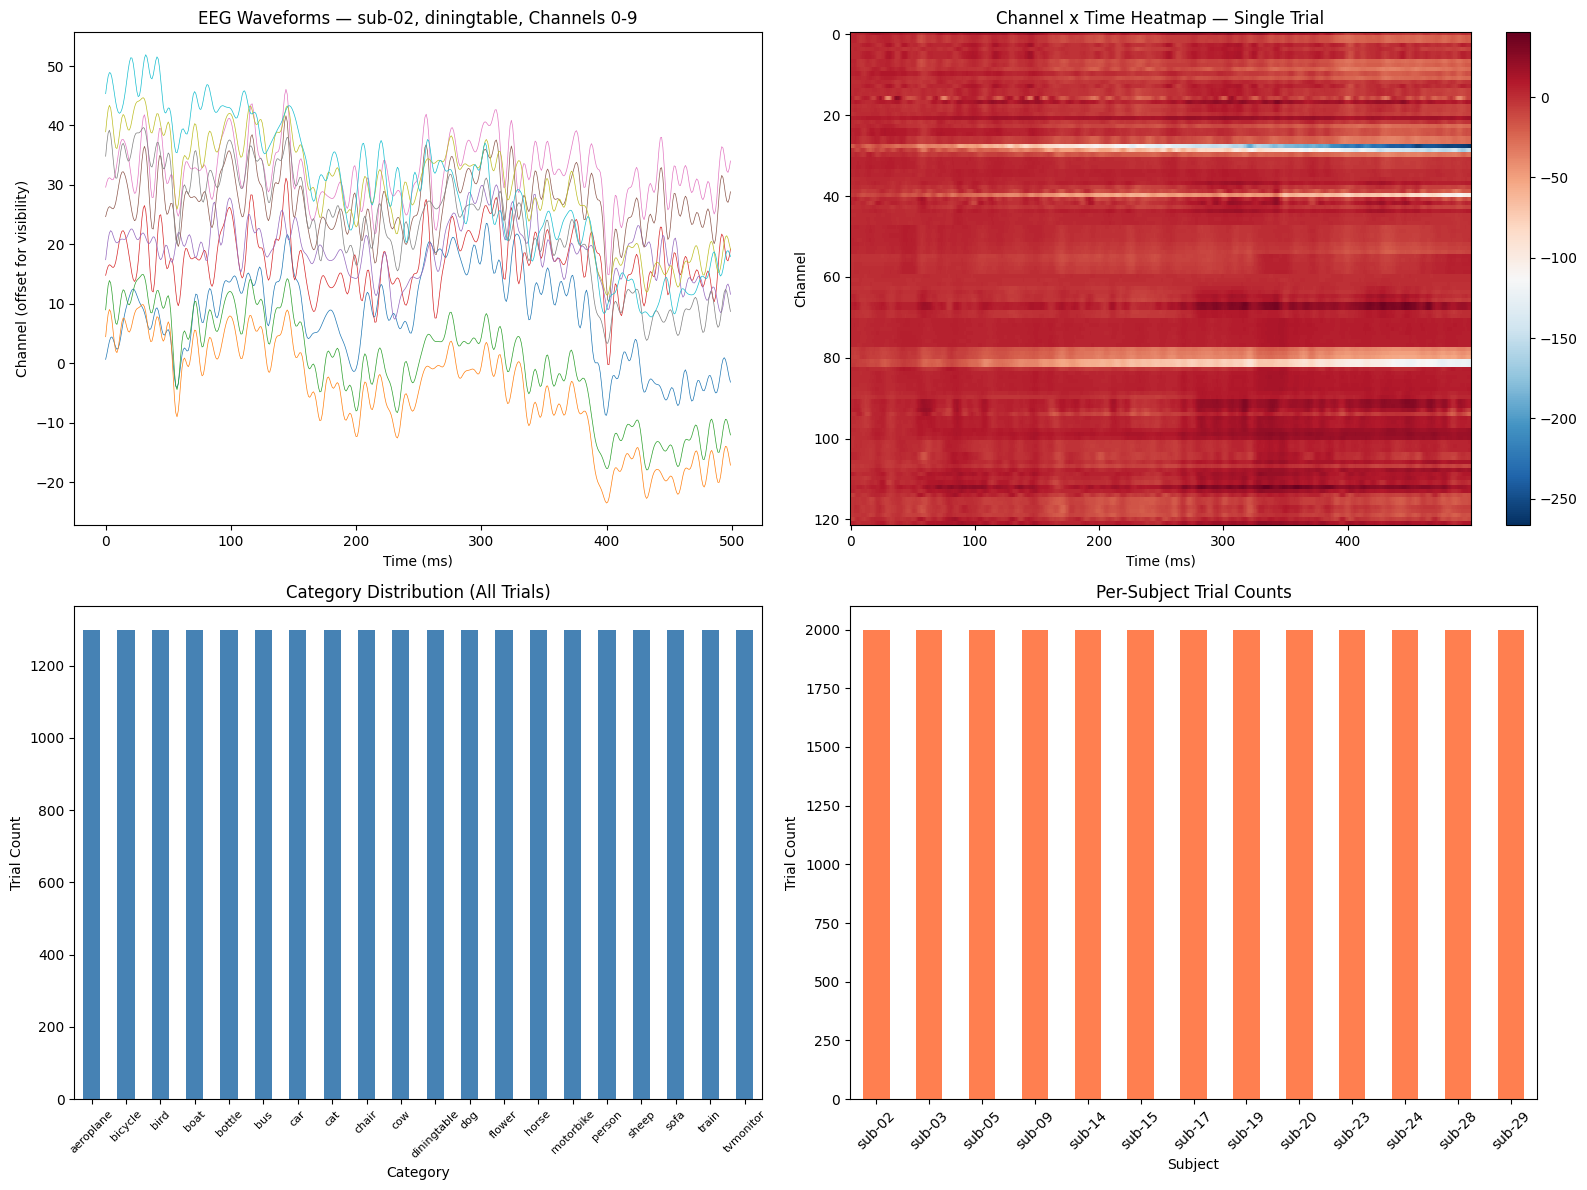

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Load one .npy for sample plots — shape is (100, 500, 122) = (trials, time, channels)
sample_row = master_df.iloc[0]
sample_eeg = np.load(sample_row['npy_path'])
trial_0 = sample_eeg[sample_row['trial_idx']]  # (500, 122)
# Transpose to (channels, time) for plotting
trial_0_ct = trial_0.T  # (122, 500)

# ── 1. Sample EEG waveforms (first 10 channels) ──
ax = axes[0, 0]
for ch in range(10):
    ax.plot(trial_0_ct[ch] + ch * 5, linewidth=0.5, label=f'Ch {ch}')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Channel (offset for visibility)')
ax.set_title(f'EEG Waveforms — {sample_row["subject"]}, '
             f'{sample_row["category"]}, Channels 0-9')

# ── 2. Channel x Time heatmap ──
ax = axes[0, 1]
im = ax.imshow(trial_0_ct, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Channel')
ax.set_title('Channel x Time Heatmap — Single Trial')
plt.colorbar(im, ax=ax, fraction=0.046)

# ── 3. Category distribution ──
ax = axes[1, 0]
master_df['category'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_xlabel('Category')
ax.set_ylabel('Trial Count')
ax.set_title('Category Distribution (All Trials)')
ax.tick_params(axis='x', rotation=45, labelsize=8)

# ── 4. Per-subject trial counts ──
ax = axes[1, 1]
master_df['subject'].value_counts().sort_index().plot.bar(ax=ax, color='coral')
ax.set_xlabel('Subject')
ax.set_ylabel('Trial Count')
ax.set_title('Per-Subject Trial Counts')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5b. Advanced Signal Analysis

These analyses inform model architecture decisions: which time windows carry signal, how much spatial redundancy exists, and whether categories are distinguishable at the neural level.

Computing baseline-corrected grand-average ERPs (2 runs per subject)...


ERP averaging: 100%|██████████| 13/13 [00:00<00:00, 17.07it/s]


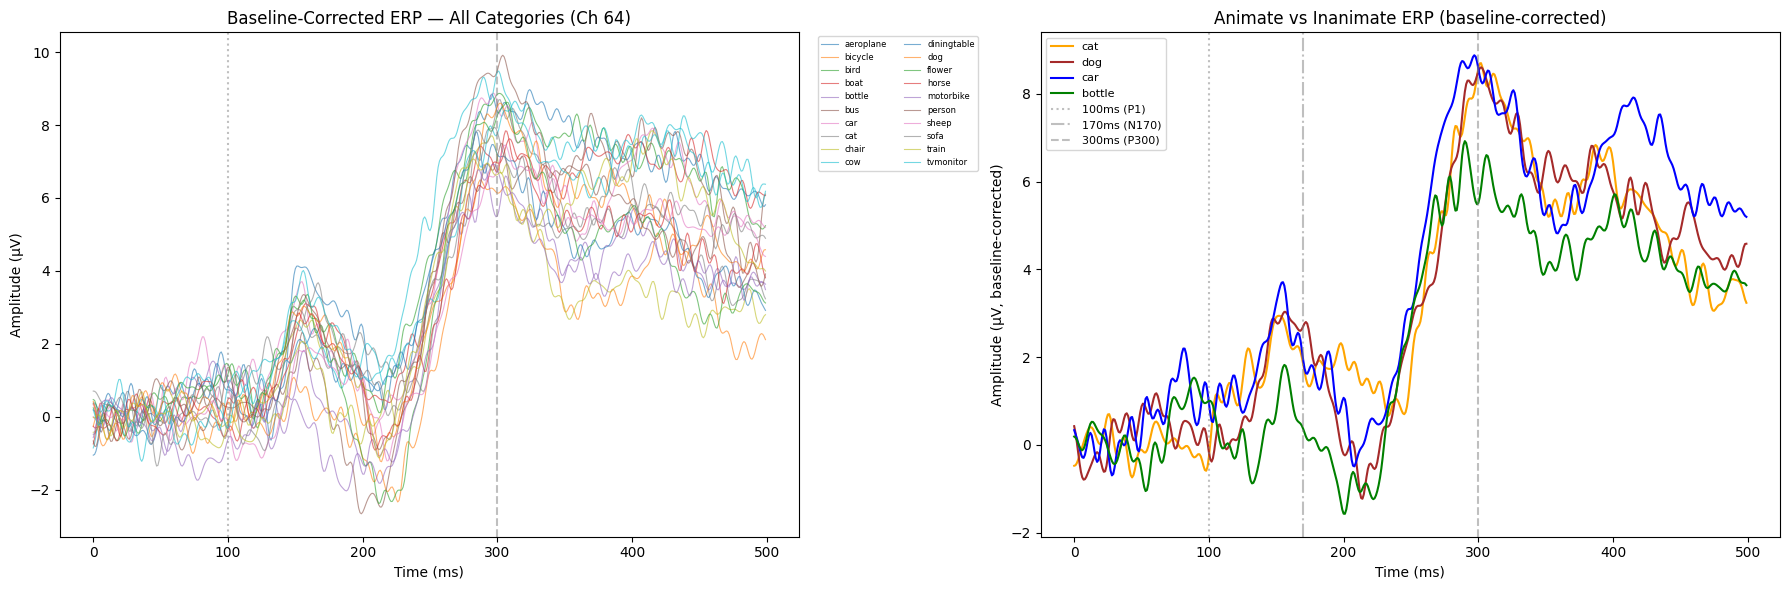

In [83]:
# === Grand-Average ERP per category (baseline-corrected) ===
# Subtract the mean of the first 50ms from each trial to remove slow drift.
# Without baseline correction, monotonically increasing variance at late
# timepoints is likely drift artifact, not genuine category-specific activity.

print("Computing baseline-corrected grand-average ERPs (2 runs per subject)...")
erp_by_cat = defaultdict(list)

for sub in tqdm(SUBJECTS, desc="ERP averaging"):
    sub_train = train_df[train_df['subject'] == sub]
    sample_paths = sub_train['npy_path'].unique()[:2]

    for npy_path in sample_paths:
        eeg = np.load(npy_path).astype(np.float32)  # (100, 500, 122)
        run_trials = sub_train[sub_train['npy_path'] == npy_path]

        for _, row in run_trials.iterrows():
            trial = np.clip(eeg[row['trial_idx']], -CLIP_THRESHOLD, CLIP_THRESHOLD)  # (500, 122)
            # Baseline correction: subtract mean of first 50ms per channel
            baseline = trial[:50, :].mean(axis=0, keepdims=True)  # (1, 122)
            trial = trial - baseline
            erp_by_cat[row['category']].append(trial)

# Grand average per category: (500, 122)
erp_avg = {cat: np.mean(trials, axis=0) for cat, trials in erp_by_cat.items()}

# Plot: overlay all categories at a central channel
central_ch = 64
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
for cat in sorted(erp_avg.keys()):
    ax.plot(erp_avg[cat][:, central_ch], linewidth=0.8, alpha=0.6, label=cat)
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=300, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title(f'Baseline-Corrected ERP — All Categories (Ch {central_ch})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6, ncol=2)

ax = axes[1]
for cat, color in [('cat', 'orange'), ('dog', 'brown'),
                   ('car', 'blue'), ('bottle', 'green')]:
    ax.plot(erp_avg[cat][:, central_ch], linewidth=1.5, label=cat, color=color)
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.5, label='100ms (P1)')
ax.axvline(x=170, color='gray', linestyle='-.', alpha=0.5, label='170ms (N170)')
ax.axvline(x=300, color='gray', linestyle='--', alpha=0.5, label='300ms (P300)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (µV, baseline-corrected)')
ax.set_title('Animate vs Inanimate ERP (baseline-corrected)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'erp_grand_average.png'), dpi=150, bbox_inches='tight')
plt.show()

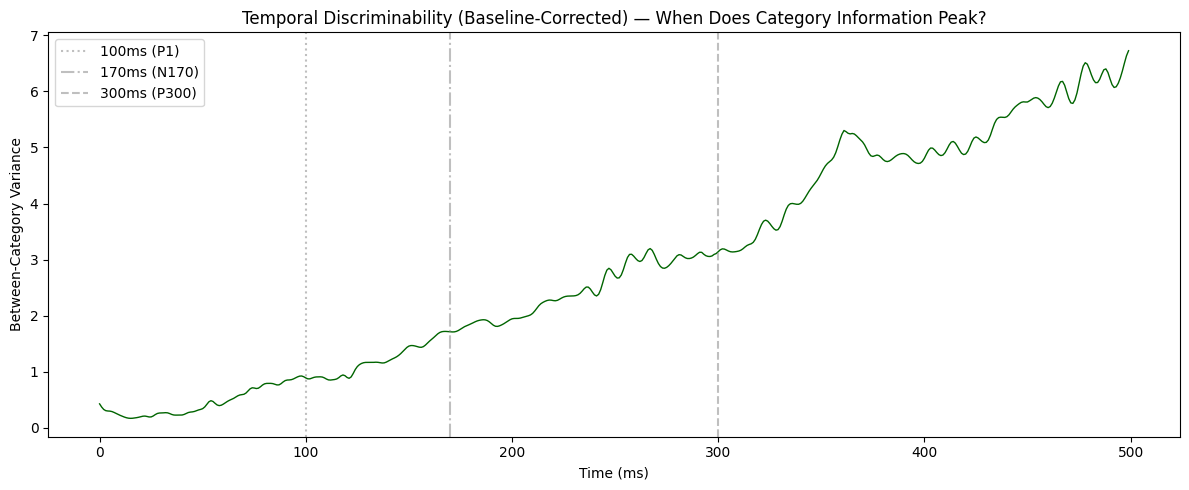

Peak between-category variance at t=499ms
Discriminative window (>50% peak): 319ms — 499ms
  → Consider cropping input to [269:500] (280 timepoints) to reduce noise and model size


In [84]:
# === Temporal discriminability: when does category information peak? ===
# Uses baseline-corrected ERPs from cell above (first 50ms mean subtracted)
all_cats = sorted(erp_avg.keys())
erp_stack = np.stack([erp_avg[c] for c in all_cats])  # (20, 500, 122)

# Between-category variance at each timepoint, averaged across channels
between_var = erp_stack.var(axis=0).mean(axis=1)  # (500,)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(between_var, linewidth=1.0, color='darkgreen')
ax.axvline(x=100, color='gray', linestyle=':', alpha=0.5, label='100ms (P1)')
ax.axvline(x=170, color='gray', linestyle='-.', alpha=0.5, label='170ms (N170)')
ax.axvline(x=300, color='gray', linestyle='--', alpha=0.5, label='300ms (P300)')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Between-Category Variance')
ax.set_title('Temporal Discriminability (Baseline-Corrected) — When Does Category Information Peak?')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'temporal_snr.png'), dpi=150, bbox_inches='tight')
plt.show()

peak_t = np.argmax(between_var)
threshold = 0.5 * between_var.max()
above = np.where(between_var > threshold)[0]
print(f"Peak between-category variance at t={peak_t}ms")
if len(above) > 0:
    print(f"Discriminative window (>50% peak): {above[0]}ms — {above[-1]}ms")
    print(f"  → Consider cropping input to [{max(0,above[0]-50)}:{min(500,above[-1]+50)}] "
          f"({above[-1]-above[0]+100} timepoints) to reduce noise and model size")

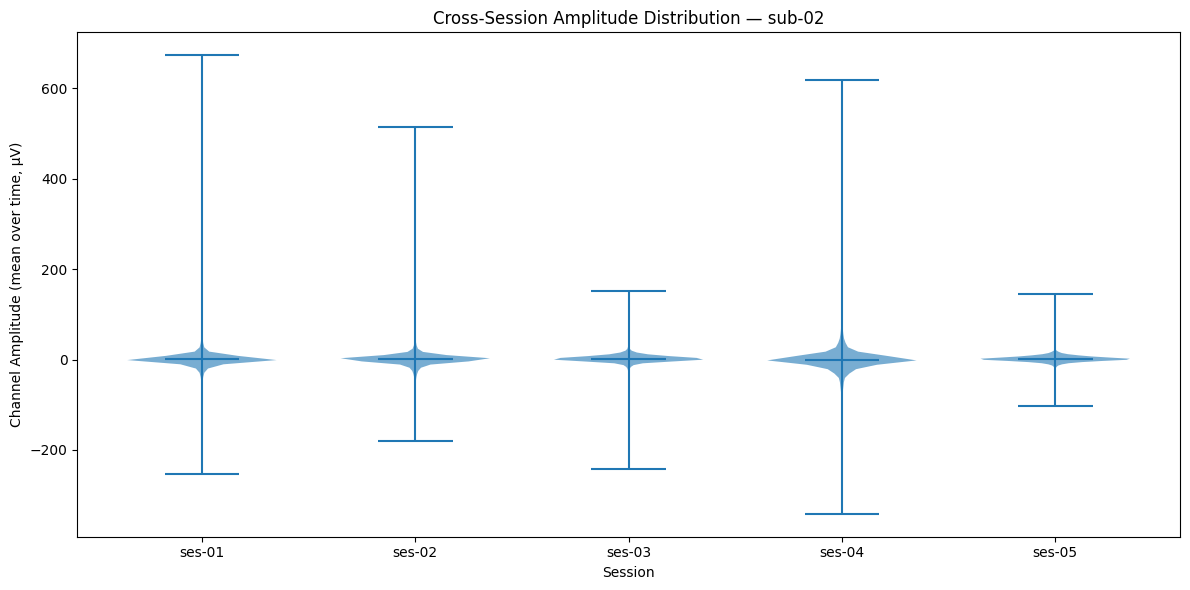

→ If distributions shift noticeably across sessions, session-based splits are well-motivated
  (prevents the model from memorizing session-specific artifacts).


In [85]:
# === Cross-session variability ===
# For one clean subject, plot amplitude distributions across sessions
# to show how much signal drifts and justify session-based splits.

test_sub = 'sub-02'
fig, ax = plt.subplots(figsize=(12, 6))
session_data = []
for ses in SESSIONS:
    sub_ses_df = master_df[(master_df['subject'] == test_sub) & (master_df['session'] == ses)]
    npy_paths = sub_ses_df['npy_path'].unique()
    all_vals = []
    for npy_path in npy_paths:
        eeg = np.load(npy_path).astype(np.float32)
        trial_idxs = sub_ses_df[sub_ses_df['npy_path'] == npy_path]['trial_idx'].values
        trials = np.clip(eeg[trial_idxs], -CLIP_THRESHOLD, CLIP_THRESHOLD)
        ch_means = trials.mean(axis=1)  # (N, 122) — mean over time per channel
        all_vals.append(ch_means.flatten())
    session_data.append(np.concatenate(all_vals))

parts = ax.violinplot(session_data, positions=range(1, 6), showmeans=True, widths=0.7)
for pc in parts['bodies']:
    pc.set_alpha(0.6)
ax.set_xlabel('Session')
ax.set_ylabel('Channel Amplitude (mean over time, µV)')
ax.set_title(f'Cross-Session Amplitude Distribution — {test_sub}')
ax.set_xticks(range(1, 6))
ax.set_xticklabels(SESSIONS)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cross_session_variability.png'), dpi=150, bbox_inches='tight')
plt.show()
print("→ If distributions shift noticeably across sessions, session-based splits"
      " are well-motivated\n  (prevents the model from memorizing session-specific artifacts).")

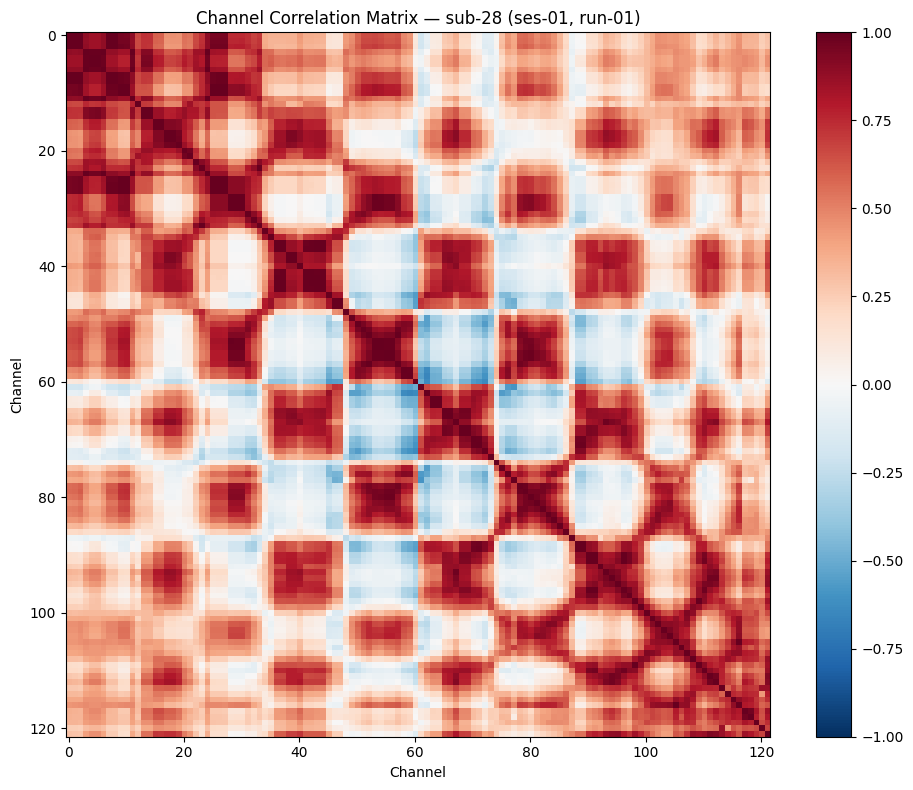

PCA dimensionality:
  13 of 122 components explain 95% of variance
  36 of 122 components explain 99% of variance
  → Significant spatial redundancy. Consider:
    - Spatial dropout during training (drop entire channels)
    - Channel grouping / pooling in early conv layers
    - PCA reduction as a preprocessing step (if model is too large)


In [86]:
# === Channel correlation matrix — identify spatial redundancy ===
sample_sub = 'sub-28'  # cleanest subject (lowest std)
sample_path = os.path.join(
    EEG_ROOT, sample_sub, 'ses-01',
    f'{sample_sub}_ses-01_task-lowSpeed_run-01_1000Hz.npy'
)
eeg_corr = np.load(sample_path).astype(np.float32)  # (100, 500, 122)
eeg_flat = eeg_corr.reshape(-1, 122)  # (50000, 122)
corr_matrix = np.corrcoef(eeg_flat.T)  # (122, 122)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, interpolation='nearest')
ax.set_xlabel('Channel')
ax.set_ylabel('Channel')
ax.set_title(f'Channel Correlation Matrix — {sample_sub} (ses-01, run-01)')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'channel_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

# PCA: how many components explain 95% of variance?
eigenvalues = np.linalg.eigvalsh(corr_matrix)[::-1]
cumvar = np.cumsum(eigenvalues) / eigenvalues.sum()
n_95 = np.searchsorted(cumvar, 0.95) + 1
n_99 = np.searchsorted(cumvar, 0.99) + 1
print(f"PCA dimensionality:")
print(f"  {n_95} of 122 components explain 95% of variance")
print(f"  {n_99} of 122 components explain 99% of variance")
print(f"  → Significant spatial redundancy. Consider:")
print(f"    - Spatial dropout during training (drop entire channels)")
print(f"    - Channel grouping / pooling in early conv layers")
print(f"    - PCA reduction as a preprocessing step (if model is too large)")

## 6. Train / Val / Test Split (by Session)

In [87]:
TRAIN_SESSIONS = ['ses-01', 'ses-02', 'ses-03']
VAL_SESSIONS   = ['ses-04']
TEST_SESSIONS  = ['ses-05']

train_df = master_df[master_df['session'].isin(TRAIN_SESSIONS)].reset_index(drop=True)
val_df   = master_df[master_df['session'].isin(VAL_SESSIONS)].reset_index(drop=True)
test_df  = master_df[master_df['session'].isin(TEST_SESSIONS)].reset_index(drop=True)

print(f"Train: {len(train_df):>6,} trials  (sessions {TRAIN_SESSIONS})")
print(f"Val:   {len(val_df):>6,} trials  (sessions {VAL_SESSIONS})")
print(f"Test:  {len(test_df):>6,} trials  (sessions {TEST_SESSIONS})")
print(f"Total: {len(train_df)+len(val_df)+len(test_df):>6,}")

# ── Verify zero overlap ──
def make_keys(df):
    return set(zip(df['subject'], df['session'], df['run'], df['trial_idx']))

tr_k, va_k, te_k = make_keys(train_df), make_keys(val_df), make_keys(test_df)
assert len(tr_k & va_k) == 0, "Train/Val overlap!"
assert len(tr_k & te_k) == 0, "Train/Test overlap!"
assert len(va_k & te_k) == 0, "Val/Test overlap!"
print("No overlap between splits")

# ── Class balance per split ──
balance = pd.DataFrame({
    'train': train_df['category'].value_counts().sort_index(),
    'val':   val_df['category'].value_counts().sort_index(),
    'test':  test_df['category'].value_counts().sort_index(),
})
print("\n=== Class Balance ===")
display(balance)

Train: 15,600 trials  (sessions ['ses-01', 'ses-02', 'ses-03'])
Val:    5,200 trials  (sessions ['ses-04'])
Test:   5,200 trials  (sessions ['ses-05'])
Total: 26,000
No overlap between splits

=== Class Balance ===


,train,val,test
category,,,
aeroplane,780,260,260
bicycle,780,260,260
bird,780,260,260
boat,780,260,260
bottle,780,260,260
bus,780,260,260
car,780,260,260
cat,780,260,260
chair,780,260,260


### Compute Per-Subject Per-Channel Normalization Stats (from training set only)

This avoids data leakage — stats are computed only on train sessions, then applied to val/test.
Amplitude clipping at a percentile-based threshold tames outlier subjects (sub-03, sub-19).

In [88]:
# Compute per-subject, per-channel mean/std from TRAINING data only
# Shape reminder: each .npy is (100, 500, 122) = (trials, timepoints, channels)
# After transpose → (channels, timepoints) — stats are per channel.

CLIP_THRESHOLD = 800.0  # clip extreme amplitudes before computing stats

norm_stats = {}  # subject -> {'mean': (122,), 'std': (122,)}

for sub in tqdm(SUBJECTS, desc="Computing norm stats"):
    all_channels = []  # will collect (N_trials * 500, 122)
    train_sub = train_df[train_df['subject'] == sub]
    npy_paths = train_sub['npy_path'].unique()

    for npy_path in npy_paths:
        eeg = np.load(npy_path).astype(np.float32)  # (100, 500, 122)
        # Get trial indices for this file from train_df
        trial_idxs = train_sub[train_sub['npy_path'] == npy_path]['trial_idx'].values
        trials = eeg[trial_idxs]  # (N, 500, 122)
        # Clip before computing stats
        trials = np.clip(trials, -CLIP_THRESHOLD, CLIP_THRESHOLD)
        # Reshape to (N*500, 122) for per-channel stats
        trials_flat = trials.reshape(-1, 122)
        all_channels.append(trials_flat)

    all_channels = np.concatenate(all_channels, axis=0)  # (total_timepoints, 122)
    norm_stats[sub] = {
        'mean': all_channels.mean(axis=0),   # (122,)
        'std':  all_channels.std(axis=0) + 1e-8,  # (122,)
    }

# Save for use by Person 2/3
with open(os.path.join(OUTPUT_DIR, 'norm_stats.pkl'), 'wb') as f:
    pickle.dump({'clip_threshold': CLIP_THRESHOLD, 'per_subject': norm_stats}, f)

# Print summary
print(f"\nNormalization stats computed for {len(norm_stats)} subjects")
print(f"Clip threshold: +/- {CLIP_THRESHOLD}")
for sub in sorted(norm_stats.keys()):
    s = norm_stats[sub]
    print(f"  {sub}: channel mean range [{s['mean'].min():.2f}, {s['mean'].max():.2f}], "
          f"channel std range [{s['std'].min():.2f}, {s['std'].max():.2f}]")

Computing norm stats: 100%|██████████| 13/13 [03:04<00:00, 14.22s/it]


Normalization stats computed for 13 subjects
Clip threshold: +/- 800.0
  sub-02: channel mean range [-3.32, 7.48], channel std range [3.39, 66.68]
  sub-03: channel mean range [-12.44, 0.90], channel std range [5.69, 91.76]
  sub-05: channel mean range [-6.20, 4.22], channel std range [3.07, 39.89]
  sub-09: channel mean range [-3.25, 7.71], channel std range [0.88, 32.47]
  sub-14: channel mean range [-7.86, 10.06], channel std range [2.90, 30.80]
  sub-15: channel mean range [-9.22, 7.00], channel std range [2.98, 50.41]
  sub-17: channel mean range [-15.77, 8.25], channel std range [2.28, 45.32]
  sub-19: channel mean range [-8.84, 5.92], channel std range [3.88, 440.54]
  sub-20: channel mean range [-3.93, 2.54], channel std range [3.72, 43.68]
  sub-23: channel mean range [-4.13, 10.78], channel std range [9.06, 41.06]
  sub-24: channel mean range [-6.12, 7.36], channel std range [2.32, 37.13]
  sub-28: channel mean range [-5.42, 7.71], channel std range [2.80, 19.36]
  sub-29: c

=== Per-Channel Std Analysis for Outlier Subjects ===

sub-19: median channel std = 13.46, max = 440.54
  Bad channels (std > 5x median):
    Ch  53: std = 165.41 (12.3x median)
    Ch  88: std = 440.54 (32.7x median)

sub-29: median channel std = 11.54, max = 282.37
  Bad channels (std > 5x median):
    Ch  82: std = 282.37 (24.5x median)

sub-03: median channel std = 39.11, max = 91.76
  No channels exceed 5x median threshold



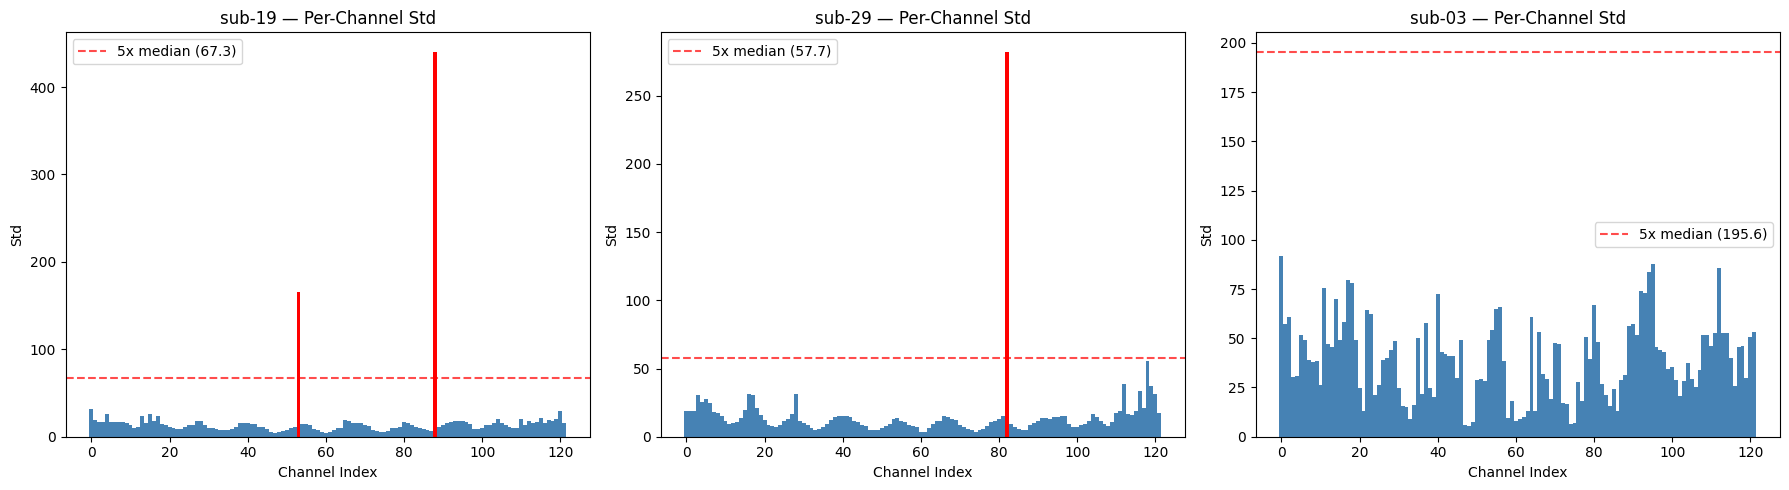

Bad channel indices saved to /jet/home/sharmar/eeg-project/artifacts/bad_channels.pkl
→ Options: zero-mask these channels, apply channel dropout, or use a tighter clip threshold


In [89]:
# === Bad channel identification for outlier subjects ===
# Sub-19 has channel std up to 440, sub-29 up to 282 — most subjects max around 30-90.
# Pinpoint which electrodes are problematic.

print("=== Per-Channel Std Analysis for Outlier Subjects ===\n")
bad_channels_by_subject = {}

for sub in ['sub-19', 'sub-29', 'sub-03']:
    ch_std = norm_stats[sub]['std']  # (122,)
    median_std = np.median(ch_std)
    # Flag channels with std > 5x median
    bad_mask = ch_std > 5 * median_std
    bad_ch = np.where(bad_mask)[0]
    bad_channels_by_subject[sub] = bad_ch.tolist()

    print(f"{sub}: median channel std = {median_std:.2f}, max = {ch_std.max():.2f}")
    if len(bad_ch) > 0:
        print(f"  Bad channels (std > 5x median):")
        for ch in bad_ch:
            print(f"    Ch {ch:3d}: std = {ch_std[ch]:.2f} ({ch_std[ch]/median_std:.1f}x median)")
    else:
        print(f"  No channels exceed 5x median threshold")
    print()

# Visualize per-channel std for these subjects
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, sub in zip(axes, ['sub-19', 'sub-29', 'sub-03']):
    ch_std = norm_stats[sub]['std']
    median_std = np.median(ch_std)
    colors = ['red' if s > 5 * median_std else 'steelblue' for s in ch_std]
    ax.bar(range(122), ch_std, color=colors, width=1.0)
    ax.axhline(5 * median_std, color='red', linestyle='--', alpha=0.7,
               label=f'5x median ({5*median_std:.1f})')
    ax.set_xlabel('Channel Index')
    ax.set_ylabel('Std')
    ax.set_title(f'{sub} — Per-Channel Std')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bad_channels.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save for potential channel masking during training
with open(os.path.join(OUTPUT_DIR, 'bad_channels.pkl'), 'wb') as f:
    pickle.dump(bad_channels_by_subject, f)
print(f"Bad channel indices saved to {OUTPUT_DIR}/bad_channels.pkl")
print("→ Options: zero-mask these channels, apply channel dropout, or use a tighter clip threshold")

## 7. PyTorch Dataset & DataLoader

In [90]:
class EEGDataset(Dataset):
    """Loads EEG trials on-the-fly with per-file caching.

    Data on disk: (100, 500, 122) = (trials, timepoints, channels)
    Output:       (122, 500)      = (channels, timepoints)  — standard for conv models

    Returns:
        eeg_tensor  : (122, 500) float32
        label       : int  (category index)
        subject_id  : int  (subject index)
        metadata    : dict (includes caption for CLIP models)
    """

    def __init__(self, df, normalize='subject_channel', norm_stats=None,
                 clip_threshold=800.0, max_cache=50, bad_channels=None):
        """
        Args:
            df:              DataFrame with npy_path, trial_idx, label, subject, ...
            normalize:       'subject_channel' | 'per_trial' | 'per_channel' | None
            norm_stats:      dict of {subject: {'mean': (122,), 'std': (122,)}}
                             Required when normalize='subject_channel'.
            clip_threshold:  clip raw EEG amplitudes to [-threshold, +threshold]
                             before normalization. Set None to skip.
            max_cache:       max .npy files to cache in memory (default 50 ≈ 1.2GB).
                             With 260 total files at ~24MB each, unlimited = ~6GB.
                             Set None for unlimited if RAM allows.
            bad_channels:    dict of {subject: [list of bad channel indices]}.
                             Bad channels are zeroed out after normalization.
                             Load from artifacts/bad_channels.pkl.
        """
        self.df = df.reset_index(drop=True)
        self.normalize = normalize
        self.norm_stats = norm_stats
        self.clip_threshold = clip_threshold
        self.max_cache = max_cache
        self.bad_channels = bad_channels or {}
        self._cache = {}
        self._cache_order = []

        self.subjects = sorted(df['subject'].unique())
        self.sub_to_idx = {s: i for i, s in enumerate(self.subjects)}

    def _load_npy(self, path):
        if path not in self._cache:
            if self.max_cache and len(self._cache) >= self.max_cache:
                oldest = self._cache_order.pop(0)
                del self._cache[oldest]
            self._cache[path] = np.load(path)
            self._cache_order.append(path)
        return self._cache[path]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        eeg_all = self._load_npy(row['npy_path'])
        eeg = eeg_all[row['trial_idx']].astype(np.float32)  # (500, 122)

        # Transpose: (500, 122) -> (122, 500) = (channels, timepoints)
        eeg = eeg.T  # (122, 500)

        # Clip extreme amplitudes
        if self.clip_threshold is not None:
            eeg = np.clip(eeg, -self.clip_threshold, self.clip_threshold)

        # Normalize
        if self.normalize == 'subject_channel' and self.norm_stats is not None:
            sub = row['subject']
            mu  = self.norm_stats[sub]['mean'][:, None]   # (122, 1)
            std = self.norm_stats[sub]['std'][:, None]    # (122, 1)
            eeg = (eeg - mu) / std
        elif self.normalize == 'per_trial':
            mu, sigma = eeg.mean(), eeg.std() + 1e-8
            eeg = (eeg - mu) / sigma
        elif self.normalize == 'per_channel':
            mu    = eeg.mean(axis=1, keepdims=True)
            sigma = eeg.std(axis=1, keepdims=True) + 1e-8
            eeg = (eeg - mu) / sigma

        # Zero out bad channels (after normalization to avoid affecting stats)
        sub = row['subject']
        if sub in self.bad_channels and len(self.bad_channels[sub]) > 0:
            eeg[self.bad_channels[sub], :] = 0.0

        eeg_tensor = torch.from_numpy(eeg)  # (122, 500)
        label      = int(row['label'])
        subject_id = self.sub_to_idx[row['subject']]

        metadata = dict(
            subject    = row['subject'],
            session    = row['session'],
            run        = row['run'],
            trial_idx  = row['trial_idx'],
            category   = row['category'],
            image_name = row['image_name'],
            caption    = row.get('caption', ''),
        )
        return eeg_tensor, label, subject_id, metadata


def eeg_collate_fn(batch):
    """Stack tensors, collate metadata into dict-of-lists."""
    eegs, labels, sub_ids, metas = zip(*batch)
    return (
        torch.stack(eegs),                              # (B, 122, 500)
        torch.tensor(labels, dtype=torch.long),         # (B,)
        torch.tensor(sub_ids, dtype=torch.long),        # (B,)
        {k: [m[k] for m in metas] for k in metas[0]},  # dict of lists
    )

In [91]:
# ── Smoke test: load one batch with subject-channel normalization + bad channels ──
train_dataset = EEGDataset(
    train_df, normalize='subject_channel',
    norm_stats=norm_stats, clip_threshold=CLIP_THRESHOLD,
    bad_channels=bad_channels_by_subject,
)
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True,
    num_workers=0, collate_fn=eeg_collate_fn,
)

eeg_batch, label_batch, sub_batch, meta_batch = next(iter(train_loader))

print(f"EEG batch:     {eeg_batch.shape}   dtype={eeg_batch.dtype}")
print(f"Labels:        {label_batch.shape}  dtype={label_batch.dtype}")
print(f"Subject IDs:   {sub_batch.shape}   dtype={sub_batch.dtype}")
print(f"Metadata keys: {list(meta_batch.keys())}")
print(f"\nSample: label={label_batch[0].item()}, "
      f"subject={meta_batch['subject'][0]}, "
      f"category={meta_batch['category'][0]}")
print(f"Caption: {meta_batch['caption'][0][:80]}...")

# ── Batch-level normalization monitoring ──
batch_means = eeg_batch.mean(dim=(1, 2))  # per-sample mean
batch_stds  = eeg_batch.std(dim=(1, 2))   # per-sample std
print(f"\n--- Batch Normalization Health Check ---")
print(f"Per-sample mean:  avg={batch_means.mean():.4f}, std={batch_means.std():.4f}, "
      f"range=[{batch_means.min():.4f}, {batch_means.max():.4f}]")
print(f"Per-sample std:   avg={batch_stds.mean():.4f}, std={batch_stds.std():.4f}, "
      f"range=[{batch_stds.min():.4f}, {batch_stds.max():.4f}]")

# Flag if normalization looks off
if batch_means.abs().mean() > 0.5:
    print("⚠ Warning: batch mean far from 0 — check norm_stats computation")
if batch_stds.mean() > 3.0 or batch_stds.mean() < 0.3:
    print("⚠ Warning: batch std far from 1 — check norm_stats computation")
else:
    print("✓ Normalization looks healthy")

EEG batch:     torch.Size([64, 122, 500])   dtype=torch.float32
Labels:        torch.Size([64])  dtype=torch.int64
Subject IDs:   torch.Size([64])   dtype=torch.int64
Metadata keys: ['subject', 'session', 'run', 'trial_idx', 'category', 'image_name', 'caption']

Sample: label=12, subject=sub-14, category=flower
Caption: White flower with yellow center and green leaves...

--- Batch Normalization Health Check ---
Per-sample mean:  avg=0.0010, std=0.4484, range=[-1.2421, 2.2538]
Per-sample std:   avg=0.7405, std=0.3909, range=[0.2665, 2.4917]
✓ Normalization looks healthy


## 8. Save Artifacts

In [92]:
# ── CSVs ──
master_df.to_csv(os.path.join(OUTPUT_DIR, 'master_trials.csv'), index=False)
train_df.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test.csv'), index=False)

# ── Label mappings ──
label_mappings = {
    'cat_to_idx': cat_to_idx,
    'idx_to_cat': {v: k for k, v in cat_to_idx.items()},
    'sub_to_idx': {s: i for i, s in enumerate(sorted(master_df['subject'].unique()))},
    'idx_to_sub': {i: s for i, s in enumerate(sorted(master_df['subject'].unique()))},
}
with open(os.path.join(OUTPUT_DIR, 'label_mappings.pkl'), 'wb') as f:
    pickle.dump(label_mappings, f)

# norm_stats already saved in the normalization cell above

print(f"Artifacts saved to {OUTPUT_DIR}/")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"  {fname:30s}  {size:>10,} bytes")

print(f"\nLabel mappings preview:")
for k, v in label_mappings['cat_to_idx'].items():
    print(f"  {v:2d} -> {k}")

Artifacts saved to /jet/home/sharmar/eeg-project/artifacts/
  bad_channels.pkl                        58 bytes
  bad_channels.png                    64,727 bytes
  channel_correlation.png            102,221 bytes
  cross_session_variability.png       51,852 bytes
  eda_plots.png                      549,537 bytes
  erp_grand_average.png              618,408 bytes
  label_mappings.pkl                     569 bytes
  master_trials.csv                5,298,422 bytes
  norm_stats.pkl                      13,942 bytes
  temporal_snr.png                    89,042 bytes
  test.csv                         1,059,518 bytes
  train.csv                        3,178,908 bytes
  val.csv                          1,060,142 bytes

Label mappings preview:
   0 -> aeroplane
   1 -> bicycle
   2 -> bird
   3 -> boat
   4 -> bottle
   5 -> bus
   6 -> car
   7 -> cat
   8 -> chair
   9 -> cow
  10 -> diningtable
  11 -> dog
  12 -> flower
  13 -> horse
  14 -> motorbike
  15 -> person
  16 -> sheep
  17 ->

## Usage by Person 2 / Person 3

```python
import pandas as pd, pickle
# Copy EEGDataset class and eeg_collate_fn from above, or import from a shared .py file

train_df = pd.read_csv('artifacts/train.csv')
val_df   = pd.read_csv('artifacts/val.csv')

with open('artifacts/label_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)

with open('artifacts/norm_stats.pkl', 'rb') as f:
    norm_data = pickle.load(f)

with open('artifacts/bad_channels.pkl', 'rb') as f:
    bad_channels = pickle.load(f)

# Person 2 (MLP): standard usage
train_ds = EEGDataset(train_df, normalize='subject_channel',
                      norm_stats=norm_data['per_subject'],
                      clip_threshold=norm_data['clip_threshold'],
                      bad_channels=bad_channels)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          collate_fn=eeg_collate_fn, num_workers=4)

# Person 3 (CLIP): access captions via metadata['caption']
for eeg, labels, sub_ids, meta in train_loader:
    captions = meta['caption']  # list of strings for CLIP text encoder
    # eeg: (B, 122, 500), labels: (B,), captions: list[str]
    break
```